In [ ]:
import os
import pandas as pd
from sklearn.model_selection import train_test_split

from google.colab import drive
drive.mount('/content/drive')

# Paths & parameters
HAM_DIR = '/content/drive/MyDrive/DermDataset'
PROC_DIR = '/content/processed_skin'


FITZ_META = "/content/drive/MyDrive/fitzpatrick17k.csv"
FITZ_IMG_DIR = "/content/drive/MyDrive/Fitzpatrick17k/images"
FITZ_OUT_DIR = "/content/drive/MyDrive/Fitzpatrick17k/CLASS_SPLIT"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
classes = ["Melanoma", "BCC", "Benign_keratosis", "Melanocytic_Nevi"]


def count_ham_images(ham_dir):
    counts = {}
    for c in classes:
        folder = os.path.join(ham_dir, c)
        if os.path.isdir(folder):
            counts[c] = len([f for f in os.listdir(folder) if f.lower().endswith((".jpg",".png",".jpeg"))])
        else:
            counts[c] = 0
    return counts

ham_counts = count_ham_images(HAM_DIR)
print("HAM10000 counts per class:", ham_counts)

HAM10000 counts per class: {'Melanoma': 750, 'BCC': 750, 'Benign_keratosis': 750, 'Melanocytic_Nevi': 750}


In [ ]:

df = pd.read_csv(FITZ_META)

# MEL
fitz_mel = df[df['label'].str.contains("melanoma", case=False, na=False)]
# BCC
fitz_bcc = df[df['label'].str.contains("basal cell carcinoma", case=False, na=False)]
# NV
fitz_nv = df[df['label'].str.contains("nevus", case=False, na=False)]
# BKL → ONLY "seborrheic keratosis"
fitz_bkl = df[df['label'].str.contains("seborrheic keratosis", case=False, na=False)]

print("Fitzpatrick counts:")
print("MEL:", len(fitz_mel))
print("BCC:", len(fitz_bcc))
print("NV :", len(fitz_nv))
print("BKL:", len(fitz_bkl))


Fitzpatrick counts:
MEL: 490
BCC: 596
NV : 485
BKL: 69


In [ ]:
# ==========================
# Sampling parameters
# ==========================
N_HAM_PER_CLASS = 750
N_FITZ_PER_CLASS = 750

# 1) Sample up to 750 images per class from HAM folders
def sample_ham(ham_dir, n_per_class=750):
    paths = []
    labels = []
    for c in classes:
        folder = os.path.join(ham_dir, c)
        if not os.path.isdir(folder):
            print(f"Warning: folder not found for class {c}: {folder}")
            continue

        files = [os.path.join(folder, f) for f in os.listdir(folder)
                 if f.lower().endswith((".jpg", ".jpeg", ".png"))]

        # sort for reproducibility
        files = sorted(files)
        selected = files[:min(len(files), n_per_class)]

        paths.extend(selected)
        labels.extend([c] * len(selected))

    return pd.DataFrame({"path": paths, "dx": labels})

ham_sampled = sample_ham(HAM_DIR, N_HAM_PER_CLASS)
print("\nHAM sampled counts:")
print(ham_sampled['dx'].value_counts())


# 2) Build Fitzpatrick sampled DataFrames (up to 750 per class)
import numpy as np

def build_fitz_df(subset, label_name, n_per_class=750):
    if len(subset) == 0:
        return pd.DataFrame(columns=["path", "dx"])

    subset_s = subset.sample(min(len(subset), n_per_class), random_state=42)
    paths = subset_s['url_alphanum'].astype(str).apply(
        lambda x: os.path.join(FITZ_IMG_DIR, x + ".jpg")
    )
    return pd.DataFrame({
        "path": paths,
        "dx": label_name
    })

fitz_mel_df = build_fitz_df(fitz_mel, "Melanoma", N_FITZ_PER_CLASS)
fitz_bcc_df = build_fitz_df(fitz_bcc, "BCC", N_FITZ_PER_CLASS)
fitz_nv_df  = build_fitz_df(fitz_nv,  "Melanocytic_Nevi", N_FITZ_PER_CLASS)
fitz_bkl_df = build_fitz_df(fitz_bkl, "Benign_keratosis", N_FITZ_PER_CLASS)  # will cap at 69

fitz_all = pd.concat([fitz_mel_df, fitz_bcc_df, fitz_nv_df, fitz_bkl_df],
                     ignore_index=True)

print("\nFitzpatrick sampled counts:")
print(fitz_all['dx'].value_counts())


# 3) Combine HAM + Fitzpatrick
combined = pd.concat([ham_sampled, fitz_all], ignore_index=True)
combined = combined.sample(frac=1, random_state=42).reset_index(drop=True)

print("\nCombined dataset counts:")
print(combined['dx'].value_counts())
print("Total images:", len(combined))


# 4) Stratified Train / Val / Test split
train_df, test_df = train_test_split(
    combined, test_size=0.15, stratify=combined['dx'], random_state=42
)

train_df, val_df = train_test_split(
    train_df, test_size=0.15, stratify=train_df['dx'], random_state=42
)

print("\nSplit sizes:")
print("Train:", len(train_df))
print("Val  :", len(val_df))
print("Test :", len(test_df))


# 5) Convert to (path, label) tuples for your dual-view pipeline
train_data = list(train_df[['path', 'dx']].itertuples(index=False, name=None))
val_data   = list(val_df[['path', 'dx']].itertuples(index=False, name=None))
test_data  = list(test_df[['path', 'dx']].itertuples(index=False, name=None))

print("\nExample train_data row:")
print(train_data[0])



HAM sampled counts:
dx
Melanoma            750
BCC                 750
Benign_keratosis    750
Melanocytic_Nevi    750
Name: count, dtype: int64

Fitzpatrick sampled counts:
dx
BCC                 596
Melanoma            490
Melanocytic_Nevi    485
Benign_keratosis     69
Name: count, dtype: int64

Combined dataset counts:
dx
BCC                 1346
Melanoma            1240
Melanocytic_Nevi    1235
Benign_keratosis     819
Name: count, dtype: int64
Total images: 4640

Split sizes:
Train: 3352
Val  : 592
Test : 696

Example train_data row:
('/content/drive/MyDrive/DermDataset/Melanoma/ISIC_6874981.jpg', 'Melanoma')


In [ ]:
import cv2
from tqdm import tqdm

SEED = 42
IMG_LESION = (128, 128)
IMG_CONTEXT = (224, 224)
N_HAM_PER_CLASS = 750  # max HAM images per class

# 1) Build a dataframe of all HAM images (then sample up to 750/class)
rows = []
for c in classes:  # ["Melanoma","BCC","Benign_keratosis","Melanocytic_Nevi"]
    folder = os.path.join(HAM_DIR, c)
    if not os.path.isdir(folder):
        print(f"Warning: HAM folder missing for class {c}: {folder}")
        continue
    for fname in os.listdir(folder):
        if fname.lower().endswith((".jpg", ".jpeg", ".png")):
            rows.append((os.path.join(folder, fname), c))

ham_df = pd.DataFrame(rows, columns=["path", "dx"])
print("\nTotal HAM images found:", len(ham_df))
print("HAM per class before sampling:")
print(ham_df['dx'].value_counts())

# sample up to 750 per class from HAM
ham_sampled = (
    ham_df.groupby("dx", group_keys=False)
          .apply(lambda x: x.sample(min(len(x), N_HAM_PER_CLASS), random_state=SEED))
)
print("\nHAM after sampling (max 750 per class):")
print(ham_sampled['dx'].value_counts())

# 2) Build Fitzpatrick dataframe (use ALL available per class)
def make_fitz_df(subset, label_name):
    if len(subset) == 0:
        return pd.DataFrame(columns=["path", "dx"])
    paths = subset['url_alphanum'].astype(str).apply(
        lambda x: os.path.join(FITZ_IMG_DIR, x + ".jpg")
    )
    return pd.DataFrame({"path": paths, "dx": label_name})

fitz_mel_df = make_fitz_df(fitz_mel, "Melanoma")
fitz_bcc_df = make_fitz_df(fitz_bcc, "BCC")
fitz_nv_df  = make_fitz_df(fitz_nv,  "Melanocytic_Nevi")
fitz_bkl_df = make_fitz_df(fitz_bkl, "Benign_keratosis")

fitz_all = pd.concat([fitz_mel_df, fitz_bcc_df, fitz_nv_df, fitz_bkl_df],
                     ignore_index=True)
print("\nFitzpatrick images used (ALL available per class):")
print(fitz_all['dx'].value_counts())

# 3) Combine HAM + Fitz
combined = pd.concat([ham_sampled, fitz_all], ignore_index=True)
combined = combined.sample(frac=1, random_state=SEED).reset_index(drop=True)

print("\nCombined dataset class counts:")
print(combined['dx'].value_counts())
print("Total images in combined dataset:", len(combined))

# 4) Stratified train/val/test split (70/15/15)
train_df, temp_df = train_test_split(
    combined,
    test_size=0.30,
    stratify=combined['dx'],
    random_state=SEED
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df['dx'],
    random_state=SEED
)

print("\nSplit sizes:")
print("Train:", len(train_df))
print("Val  :", len(val_df))
print("Test :", len(test_df))

print("\nTrain class counts:")
print(train_df['dx'].value_counts())
print("\nVal class counts:")
print(val_df['dx'].value_counts())
print("\nTest class counts:")
print(test_df['dx'].value_counts())

# 5) Crop function (like in your py file)
def create_crops(img, out_lesion=(128,128), out_context=(224,224)):
    h, w = img.shape[:2]
    cx, cy = w // 2, h // 2

    # lesion crop ~ central 40% of min dimension
    l = int(min(w, h) * 0.4)
    x1 = max(cx - l // 2, 0); y1 = max(cy - l // 2, 0)
    x2 = min(cx + l // 2, w); y2 = min(cy + l // 2, h)
    lesion = img[y1:y2, x1:x2]
    lesion = cv2.resize(lesion, out_lesion)

    # context crop ~ central 90% of min dimension
    L = int(min(w, h) * 0.9)
    x1 = max(cx - L // 2, 0); y1 = max(cy - L // 2, 0)
    x2 = min(cx + L // 2, w); y2 = min(cy + L // 2, h)
    context = img[y1:y2, x1:x2]
    context = cv2.resize(context, out_context)

    return lesion, context

# 6) Prepare PROC_DIR structure (train/val/test × class × lesion/context)
for split in ['train', 'val', 'test']:
    for cls in classes:
        os.makedirs(os.path.join(PROC_DIR, split, cls, 'lesion'), exist_ok=True)
        os.makedirs(os.path.join(PROC_DIR, split, cls, 'context'), exist_ok=True)

# 7) Apply cropping & save into PROC_DIR, following your methodology
split_map = {
    'train': train_df,
    'val':   val_df,
    'test':  test_df
}

for split_name, df_split in split_map.items():
    print(f"\nProcessing {split_name} split...")
    for _, row in tqdm(df_split.iterrows(), total=len(df_split)):
        img_path = row['path']
        cls = row['dx']

        img = cv2.imread(img_path)
        if img is None:
            continue

        lesion, context = create_crops(img, IMG_LESION, IMG_CONTEXT)

        base = os.path.join(PROC_DIR, split_name, cls)
        fname = os.path.basename(img_path)

        cv2.imwrite(os.path.join(base, 'lesion', fname), lesion)
        cv2.imwrite(os.path.join(base, 'context', fname), context)

print("\nProcessing done. Crops saved in", PROC_DIR)


/tmp/ipython-input-1850830769.py:28: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(min(len(x), N_HAM_PER_CLASS), random_state=SEED))



Total HAM images found: 3000
HAM per class before sampling:
dx
Melanoma            750
BCC                 750
Benign_keratosis    750
Melanocytic_Nevi    750
Name: count, dtype: int64

HAM after sampling (max 750 per class):
dx
BCC                 750
Benign_keratosis    750
Melanocytic_Nevi    750
Melanoma            750
Name: count, dtype: int64

Fitzpatrick images used (ALL available per class):
dx
BCC                 596
Melanoma            490
Melanocytic_Nevi    485
Benign_keratosis     69
Name: count, dtype: int64

Combined dataset class counts:
dx
BCC                 1346
Melanoma            1240
Melanocytic_Nevi    1235
Benign_keratosis     819
Name: count, dtype: int64
Total images in combined dataset: 4640

Split sizes:
Train: 3248
Val  : 696
Test : 696

Train class counts:
dx
BCC                 942
Melanoma            868
Melanocytic_Nevi    865
Benign_keratosis    573
Name: count, dtype: int64

Val class counts:
dx
BCC                 202
Melanoma            186
Melanoc

100%|██████████| 3248/3248 [25:29<00:00,  2.12it/s]



Processing val split...


100%|██████████| 696/696 [05:21<00:00,  2.16it/s]



Processing test split...


100%|██████████| 696/696 [05:38<00:00,  2.06it/s]


Processing done. Crops saved in /content/processed_skin


In [ ]:
import tensorflow as tf
def create_dataset(split='train'):
    lesion_paths, context_paths, labels = [], [], []
    classes = sorted([d for d in os.listdir(os.path.join(PROC_DIR, split))
                      if os.path.isdir(os.path.join(PROC_DIR, split, d))])
    class_to_idx = {c:i for i,c in enumerate(classes)}

    for cls in classes:
        ldir = os.path.join(PROC_DIR, split, cls, 'lesion')
        cdir = os.path.join(PROC_DIR, split, cls, 'context')
        for fname in os.listdir(ldir):
            lesion_paths.append(os.path.join(ldir, fname))
            context_paths.append(os.path.join(cdir, fname))
            labels.append(class_to_idx[cls])

    ds = tf.data.Dataset.from_tensor_slices((lesion_paths, context_paths, labels))

    def _load(lpath, cpath, label):
        l = tf.io.read_file(lpath); l = tf.image.decode_jpeg(l, channels=3)
        l = tf.image.convert_image_dtype(l, tf.float32); l = tf.image.resize(l, IMG_LESION)
        c = tf.io.read_file(cpath); c = tf.image.decode_jpeg(c, channels=3)
        c = tf.image.convert_image_dtype(c, tf.float32); c = tf.image.resize(c, IMG_CONTEXT)
        return (l, c), tf.one_hot(label, len(classes))

    ds = ds.map(_load, num_parallel_calls=tf.data.AUTOTUNE)
    # Removed .batch(32) from here
    # ds = ds.cache() # Removed .cache() and .shuffle() as they are applied later with batching
    # ds = ds.shuffle(buffer_size=1024)
    # ds = ds.batch(32)
    # ds = ds.prefetch(buffer_size=tf.data.AUTOTUNE)
    return ds, classes

train_ds, classes = create_dataset('train')
val_ds, _ = create_dataset('val')
test_ds, _ = create_dataset('test')
print("Classes:", classes)

Classes: ['BCC', 'Benign_keratosis', 'Melanocytic_Nevi', 'Melanoma']


In [ ]:

for batch in train_ds.take(1):
    (lesion_batch, context_batch), y_batch = batch
    print("Lesion batch shape:", lesion_batch.shape)
    print("Context batch shape:", context_batch.shape)
    print("Labels shape:", y_batch.shape)

Lesion batch shape: (128, 128, 3)
Context batch shape: (224, 224, 3)
Labels shape: (4,)


In [ ]:
BATCH_SIZE = 16

# Removed .shuffle().batch().prefetch() from here, as 'prepare' will handle it.
# The datasets train_ds, val_ds, test_ds should be unbatched when passed to prepare.

for batch in train_ds.take(1):
    (lesion_batch, context_batch), y_batch = batch
    print("Lesion batch shape:", lesion_batch.shape)
    print("Context batch shape:", context_batch.shape)
    print("Labels shape:", y_batch.shape)

Lesion batch shape: (128, 128, 3)
Context batch shape: (224, 224, 3)
Labels shape: (4,)


In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

def augment_pair(lesion, context):
    if tf.random.uniform(()) > 0.5:
        lesion = tf.image.flip_left_right(lesion); context = tf.image.flip_left_right(context)
    if tf.random.uniform(()) > 0.5:
        lesion = tf.image.flip_up_down(lesion); context = tf.image.flip_up_down(context)
    lesion = tf.image.random_brightness(lesion, 0.1)
    context = tf.image.random_brightness(context, 0.1)
    return lesion, context

def prepare(ds, training=False):
    def _process(inputs, labels):
        l, c = inputs
        if training:
            l, c = augment_pair(l, c)
        return {'lesion_input': l, 'context_input': c}, labels

    ds = ds.map(_process, num_parallel_calls=AUTOTUNE)
    if training:
        ds = ds.shuffle(512)
    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds

# IMPORTANT: train_ds, val_ds, test_ds here must be UNBATCHED
train_ds_prepared = prepare(train_ds, training=True)
val_ds_prepared   = prepare(val_ds)
test_ds_prepared  = prepare(test_ds)


In [ ]:
import numpy as np
from sklearn.utils.class_weight import compute_class_weight

train_labels = []
# Iterate over the unbatched train_ds to get individual labels
for _, y in train_ds:
    train_labels.append(np.argmax(y.numpy()))

class_weights_arr = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(len(classes)),
    y=train_labels
)
class_weights = dict(enumerate(class_weights_arr))
print("Class weights:", class_weights)

Class weights: {0: np.float64(0.9990530303030303), 1: np.float64(1.008604206500956), 2: np.float64(0.9625912408759124), 3: np.float64(1.032289628180039)}


In [ ]:
print("Classes (index order):", classes)



Classes (index order): ['BCC', 'Benign_keratosis', 'Melanocytic_Nevi', 'Melanoma']


In [ ]:
from tensorflow.keras import layers, Model, Input, optimizers

def conv_block(x, filters):
    x = layers.Conv2D(filters, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(filters, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2)(x)
    return x

# Lesion branch
inp_lesion = Input(shape=(IMG_LESION[0], IMG_LESION[1], 3), name='lesion_input')
x1 = conv_block(inp_lesion, 32)
x1 = conv_block(x1, 64)
x1 = conv_block(x1, 128)
x1 = layers.GlobalAveragePooling2D()(x1)

# Context branch
inp_context = Input(shape=(IMG_CONTEXT[0], IMG_CONTEXT[1], 3), name='context_input')
x2 = conv_block(inp_context, 32)
x2 = conv_block(x2, 64)
x2 = conv_block(x2, 128)
x2 = layers.GlobalAveragePooling2D()(x2)

# Merge
x = layers.concatenate([x1, x2])
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.5)(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.4)(x)
out = layers.Dense(len(classes), activation='softmax')(x)

model = Model([inp_lesion, inp_context], out)


In [ ]:
EPOCHS = 40

model.compile(
    optimizer=optimizers.Adam(1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ lesion_input        │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ context_input       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 128, 128,  │        896 │ lesion_input[0][… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 224, 224,  │        896 │ context_input[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 128, 128,  │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 224, 224,  │        128 │ conv2d_6[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 128, 128,  │      9,248 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 224, 224,  │      9,248 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        128 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 224, 224,  │        128 │ conv2d_7[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 112, 112,  │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 64, 64,    │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 112, 112,  │     18,496 │ max_pooling2d_3[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        256 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 112, 112,  │        256 │ conv2d_8[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 64, 64,    │     36,928 │ batch_normalizat

 Total params: 676,804 (2.58 MB)

 Trainable params: 675,012 (2.57 MB)

 Non-trainable params: 1,792 (7.00 KB)

In [ ]:
from tensorflow.keras import callbacks, optimizers



model.compile(
    optimizer=optimizers.Adam(1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

MODEL_SAVE_PATH = "/content/drive/MyDrive/derm_model3.h5"

es = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True
)

rlrop = callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=4,
    min_lr=1e-7
)

history = model.fit(
    train_ds_prepared,
    validation_data=val_ds_prepared,
    epochs=EPOCHS,
    class_weight=class_weights,
    callbacks=[es, rlrop]
)

model.save(MODEL_SAVE_PATH)


Epoch 1/40
132/132 ━━━━━━━━━━━━━━━━━━━━ 66s 280ms/step - accuracy: 0.3849 - loss: 1.4715 - val_accuracy: 0.2140 - val_loss: 1.4155 - learning_rate: 1.0000e-04
Epoch 2/40
132/132 ━━━━━━━━━━━━━━━━━━━━ 14s 100ms/step - accuracy: 0.2832 - loss: 1.6881 - val_accuracy: 0.4186 - val_loss: 1.2341 - learning_rate: 1.0000e-04
Epoch 3/40
132/132 ━━━━━━━━━━━━━━━━━━━━ 14s 100ms/step - accuracy: 0.3130 - loss: 1.5396 - val_accuracy: 0.5674 - val_loss: 1.1039 - learning_rate: 1.0000e-04
Epoch 4/40
132/132 ━━━━━━━━━━━━━━━━━━━━ 14s 101ms/step - accuracy: 0.2997 - loss: 1.5479 - val_accuracy: 0.5814 - val_loss: 1.0213 - learning_rate: 1.0000e-04
Epoch 5/40
132/132 ━━━━━━━━━━━━━━━━━━━━ 14s 101ms/step - accuracy: 0.3227 - loss: 1.4259 - val_accuracy: 0.5977 - val_loss: 0.9850 - learning_rate: 1.0000e-04
Epoch 6/40
132/132 ━━━━━━━━━━━━━━━━━━━━ 14s 102ms/step - accuracy: 0.3451 - loss: 1.4325 - val_accuracy: 0.5233 - val_loss: 1.1739 - learning_rate: 1.0000e-04
Epoch 7/40
132/132 ━━━━━━━━━━━━━━━━━━━━ 15s 10

In [ ]:

# === EVALUATION ===
from sklearn.metrics import classification_report
import pandas as pd
import numpy as np

y_prob = model.predict(test_ds_prepared)
y_pred = np.argmax(y_prob, axis=1)

y_true = []
for _, y in test_ds:
    y_true.append(np.argmax(y.numpy()))
y_true = np.array(y_true)

report_dict = classification_report(y_true, y_pred, target_names=classes, digits=4, output_dict=True)
report_df = pd.DataFrame(report_dict).transpose()
print("Classification Report (DataFrame):\n")
print(report_df)



29/29 ━━━━━━━━━━━━━━━━━━━━ 5s 122ms/step
Classification Report (DataFrame):

                  precision    recall  f1-score     support
BCC                0.842105  0.571429  0.680851  112.000000
Benign_keratosis   0.786408  0.704348  0.743119  115.000000
Melanocytic_Nevi   0.707143  0.900000  0.792000  110.000000
Melanoma           0.765957  0.878049  0.818182  123.000000
accuracy           0.765217  0.765217  0.765217    0.765217
macro avg          0.775403  0.763456  0.758538  460.000000
weighted avg       0.775546  0.765217  0.759718  460.000000


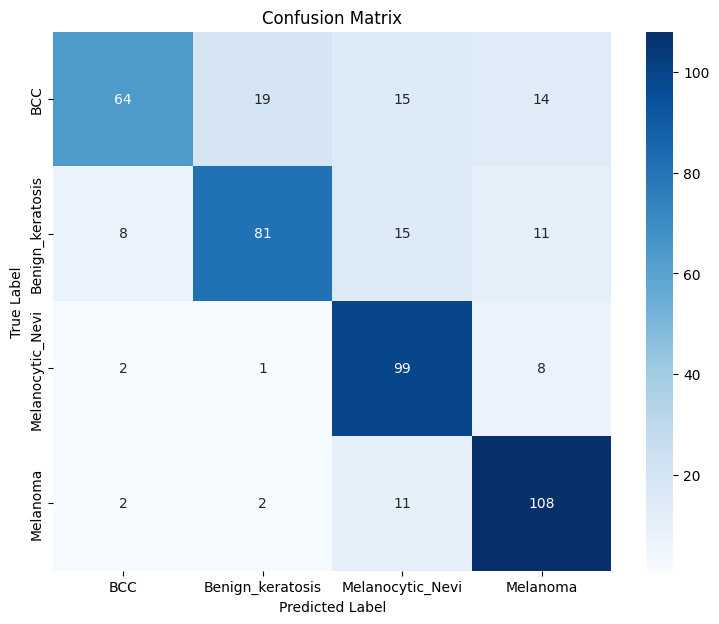


Macro F1: 0.76, Micro F1: 0.77


In [ ]:
# === CONFUSION MATRIX ===
from sklearn.metrics import confusion_matrix, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np


def plot_confusion_matrix(y_true, y_pred, labels, title="Confusion Matrix"):
    cm = confusion_matrix(y_true, y_pred)
    cm_df = pd.DataFrame(cm, index=labels, columns=labels)
    plt.figure(figsize=(9,7))
    sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues')
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(title)
    plt.show()

plot_confusion_matrix(y_true, y_pred, classes)
macro_f1 = f1_score(y_true, y_pred, average="macro")
micro_f1 = f1_score(y_true, y_pred, average="micro")
print(f"\nMacro F1: {macro_f1:.2f}, Micro F1: {micro_f1:.2f}")



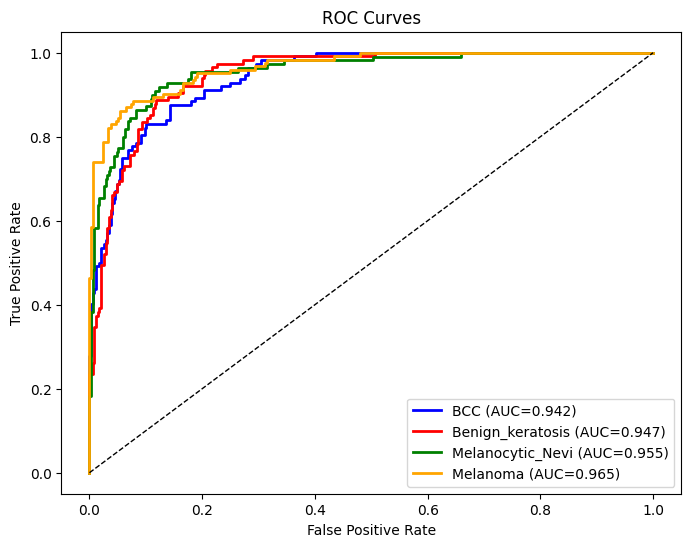

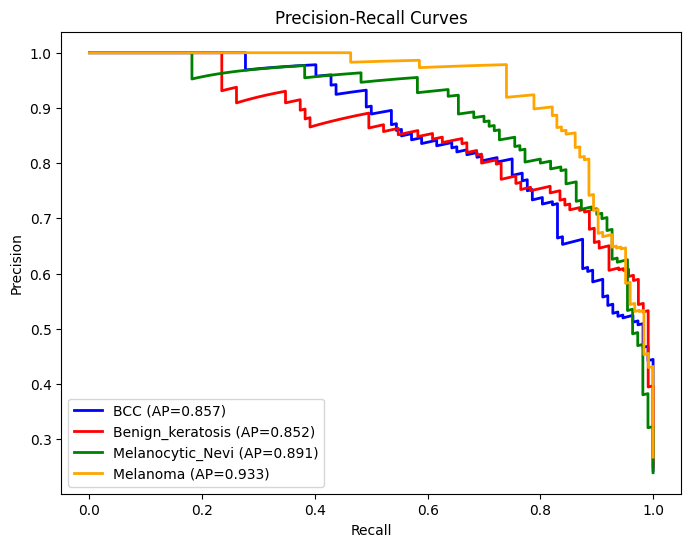

In [ ]:
# === ROC & PR CURVES ===
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score
from itertools import cycle
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

n_classes = len(classes)
y_true_onehot = tf.keras.utils.to_categorical(y_true, num_classes=n_classes)
fpr, tpr, roc_auc = {}, {}, {}
precision, recall, pr_auc = {}, {}, {}
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_onehot[:,i], y_prob[:,i])
    roc_auc[i] = auc(fpr[i], tpr[i])
    precision[i], recall[i], _ = precision_recall_curve(y_true_onehot[:,i], y_prob[:,i])
    pr_auc[i] = average_precision_score(y_true_onehot[:,i], y_prob[:,i])

plt.figure(figsize=(8,6))
colors = cycle(["blue","red","green","orange"])
for i,color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2, label=f"{classes[i]} (AUC={roc_auc[i]:.3f})")
plt.plot([0,1],[0,1],"k--", lw=1)
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate"); plt.title("ROC Curves")
plt.legend(loc="lower right"); plt.show()

plt.figure(figsize=(8,6))
for i,color in zip(range(n_classes), colors):
    plt.plot(recall[i], precision[i], color=color, lw=2, label=f"{classes[i]} (AP={pr_auc[i]:.3f})")
plt.xlabel("Recall"); plt.ylabel("Precision"); plt.title("Precision-Recall Curves")
plt.legend(loc="lower left"); plt.show()



In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import cv2
import random

def get_last_conv_layer(model):
    # Find the last Conv2D layer in the model (works with your dual-branch CNN)
    conv_layers = [layer for layer in model.layers if isinstance(layer, tf.keras.layers.Conv2D)]
    if not conv_layers:
        raise ValueError("No Conv2D layers found in model.")
    return conv_layers[-1]

def compute_gradcam_for_sample(model, lesion_img, context_img, class_index=None):
    """
    lesion_img, context_img: single images (H,W,3) in [0,1] float32
    class_index: target class index (0..num_classes-1). If None, use predicted class.
    Returns: heatmap (for the last conv layer) as 2D array in [0,1]
    """
    last_conv_layer = get_last_conv_layer(model)

    # Build a model that maps inputs -> (conv feature maps, predictions)
    grad_model = tf.keras.models.Model(
        inputs=model.inputs,
        outputs=[last_conv_layer.output, model.output]
    )

    # Add batch dimension
    inputs = {
        'lesion_input': tf.expand_dims(lesion_img, 0),
        'context_input': tf.expand_dims(context_img, 0)
    }

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(inputs)
        if class_index is None:
            class_index = tf.argmax(predictions[0])
        class_channel = predictions[:, class_index]

    # Gradients of the target class wrt conv feature maps
    grads = tape.gradient(class_channel, conv_outputs)  # (1, H', W', C)

    # Global average pool over spatial dims -> importance weights per channel
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))  # (C,)

    conv_outputs = conv_outputs[0]  # (H', W', C)
    heatmap = tf.reduce_sum(tf.multiply(conv_outputs, pooled_grads), axis=-1)

    # Normalize heatmap
    heatmap = tf.maximum(heatmap, 0) / (tf.reduce_max(heatmap) + 1e-8)
    heatmap = heatmap.numpy()
    return heatmap


The context and lesion centered Grad cam




In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import cv2
import random
from tensorflow.keras.layers import Conv2D

def get_branch_conv_layers(model):
    """
    Returns (lesion_conv_layers, context_conv_layers)
    based on the build order of your dual-branch model.
    Assumes: lesion convs created first, then context convs.
    """
    conv_layers = [layer for layer in model.layers if isinstance(layer, Conv2D)]
    if len(conv_layers) < 2:
        raise ValueError("Not enough Conv2D layers found in model.")

    # First half belong to lesion branch, second half to context branch (given your architecture)
    half = len(conv_layers) // 2
    lesion_convs  = conv_layers[:half]
    context_convs = conv_layers[half:]
    return lesion_convs, context_convs

def compute_gradcam_for_sample_branch(model, lesion_img, context_img, class_index=None, branch='context'):
    """
    branch: 'lesion' or 'context'
    Returns a 2D heatmap (0..1) for the chosen branch.
    """
    lesion_convs, context_convs = get_branch_conv_layers(model)
    if branch == 'lesion':
        last_conv_layer = lesion_convs[-1]
    else:
        last_conv_layer = context_convs[-1]

    # Build a model that maps inputs -> (conv feature maps, predictions)
    grad_model = tf.keras.models.Model(
        inputs=model.inputs,
        outputs=[last_conv_layer.output, model.output]
    )

    inputs = {
        'lesion_input': tf.expand_dims(lesion_img, 0),
        'context_input': tf.expand_dims(context_img, 0)
    }

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(inputs)
        if class_index is None:
            class_index = tf.argmax(predictions[0])
        class_channel = predictions[:, class_index]

    grads = tape.gradient(class_channel, conv_outputs)  # (1, H', W', C)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))  # (C,)

    conv_outputs = conv_outputs[0]  # (H', W', C)
    heatmap = tf.reduce_sum(conv_outputs * pooled_grads, axis=-1)

    heatmap = tf.maximum(heatmap, 0) / (tf.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()


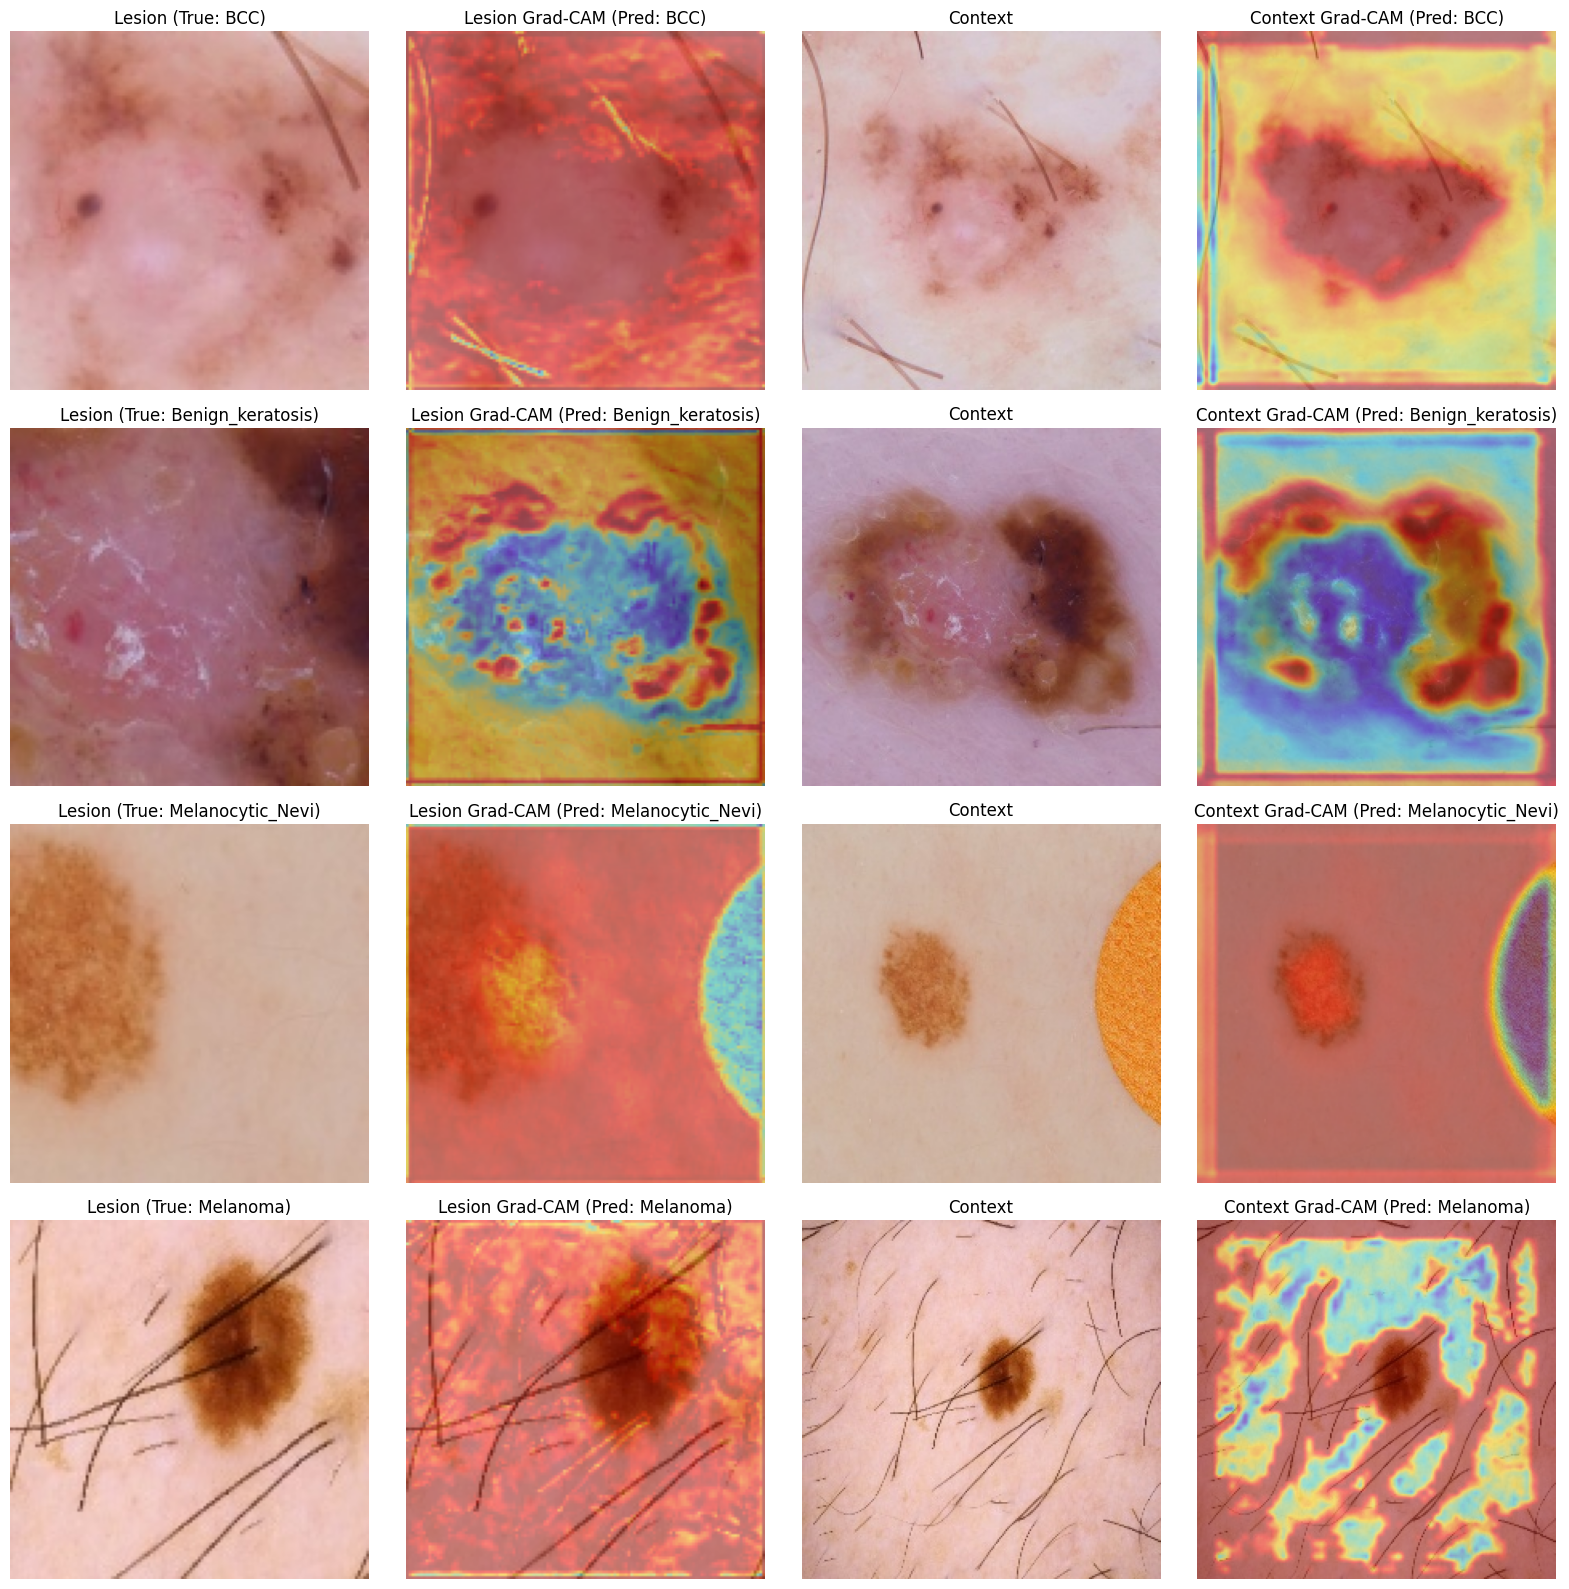

In [ ]:
def gradcam_dual_branch_multiclass(model, test_ds_prepared, classes, alpha=0.4):
    """
    For each class, this function shows lesion & context Grad-CAM overlays for one random test example.
    """
    # Collect all test samples
    all_samples = []
    all_labels = []

    for inputs, y in test_ds_prepared.unbatch():
        lesion_img = inputs['lesion_input'].numpy()
        context_img = inputs['context_input'].numpy()
        label_idx = np.argmax(y.numpy())
        all_samples.append({'lesion': lesion_img, 'context': context_img})
        all_labels.append(label_idx)

    all_labels = np.array(all_labels)
    num_classes = len(classes)

    fig, axes = plt.subplots(num_classes, 4, figsize=(16, 4 * num_classes))
    if num_classes == 1:
        axes = np.expand_dims(axes, 0)  # handle single-class edge case

    for i, cls_name in enumerate(classes):
        indices = np.where(all_labels == i)[0]
        if len(indices) == 0:
            print(f"No samples found in test set for class {cls_name}")
            continue

        idx = random.choice(indices)
        lesion_img = all_samples[idx]['lesion']
        context_img = all_samples[idx]['context']

        # Predict
        preds = model.predict(
            {
                'lesion_input': np.expand_dims(lesion_img, 0),
                'context_input': np.expand_dims(context_img, 0)
            },
            verbose=0
        )
        pred_class = np.argmax(preds[0])
        pred_name = classes[pred_class]

        # --- Grad-CAM for lesion branch ---
        lesion_heatmap = compute_gradcam_for_sample_branch(
            model, lesion_img, context_img,
            class_index=pred_class,
            branch='lesion'
        )

        lesion_disp = np.uint8(255 * lesion_img)
        lesion_heat_resized = cv2.resize(
            lesion_heatmap,
            (lesion_disp.shape[1], lesion_disp.shape[0])
        )
        lesion_heat_resized = np.uint8(255 * lesion_heat_resized)
        lesion_heat_color = cv2.applyColorMap(lesion_heat_resized, cv2.COLORMAP_JET)
        lesion_overlay = cv2.addWeighted(lesion_disp, 1 - alpha, lesion_heat_color, alpha, 0)

        # --- Grad-CAM for context branch ---
        context_heatmap = compute_gradcam_for_sample_branch(
            model, lesion_img, context_img,
            class_index=pred_class,
            branch='context'
        )

        context_disp = np.uint8(255 * context_img)
        context_heat_resized = cv2.resize(
            context_heatmap,
            (context_disp.shape[1], context_disp.shape[0])
        )
        context_heat_resized = np.uint8(255 * context_heat_resized)
        context_heat_color = cv2.applyColorMap(context_heat_resized, cv2.COLORMAP_JET)
        context_overlay = cv2.addWeighted(context_disp, 1 - alpha, context_heat_color, alpha, 0)

        # --- Plot 4 columns: lesion original, lesion CAM, context original, context CAM ---
        axes[i, 0].imshow(lesion_disp)
        axes[i, 0].set_title(f"Lesion (True: {cls_name})")
        axes[i, 0].axis("off")

        axes[i, 1].imshow(lesion_overlay)
        axes[i, 1].set_title(f"Lesion Grad-CAM (Pred: {pred_name})")
        axes[i, 1].axis("off")

        axes[i, 2].imshow(context_disp)
        axes[i, 2].set_title("Context")
        axes[i, 2].axis("off")

        axes[i, 3].imshow(context_overlay)
        axes[i, 3].set_title(f"Context Grad-CAM (Pred: {pred_name})")
        axes[i, 3].axis("off")

    plt.tight_layout()
    plt.show()

gradcam_dual_branch_multiclass(model, test_ds_prepared, classes, alpha=0.4)
